In [16]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE
from MDP.STIRFutures.BARCHART.BarchartFetcher import BarchartFetcher

from BT.misc import ql_cal_date_range

In [18]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")

In [22]:
# ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-OIS-Q8xM12", timestamp=ts, kwargs=dict(force_refresh=False))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts, kwargs=dict(force_refresh=True))

# timestamps = ql_cal_date_range(
#     ql.UnitedStates(ql.UnitedStates.GovernmentBond),
#     start=NY_tz.localize(datetime.datetime(2026, 2, 17, 1, 50)),
#     end=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     freq="1min",
# )
# timestamps = pd.date_range(NY_tz.localize(datetime.datetime(2026, 2, 17, 16, 50)), NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)), freq="1min").to_list()

curves = bc_stirf_curve.build_curve(
    curve_name="USD-SOFR-1D-Q8",
    timestamp=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
	# timestamp=timestamps,
    # kwargs={"force_refresh": False},
)
curves 

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.040106518595657385, `time`: 0.0219s


<rl.Curve:USD-SOFR-1D at 0x2273e55b150>

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x2273e547890>])

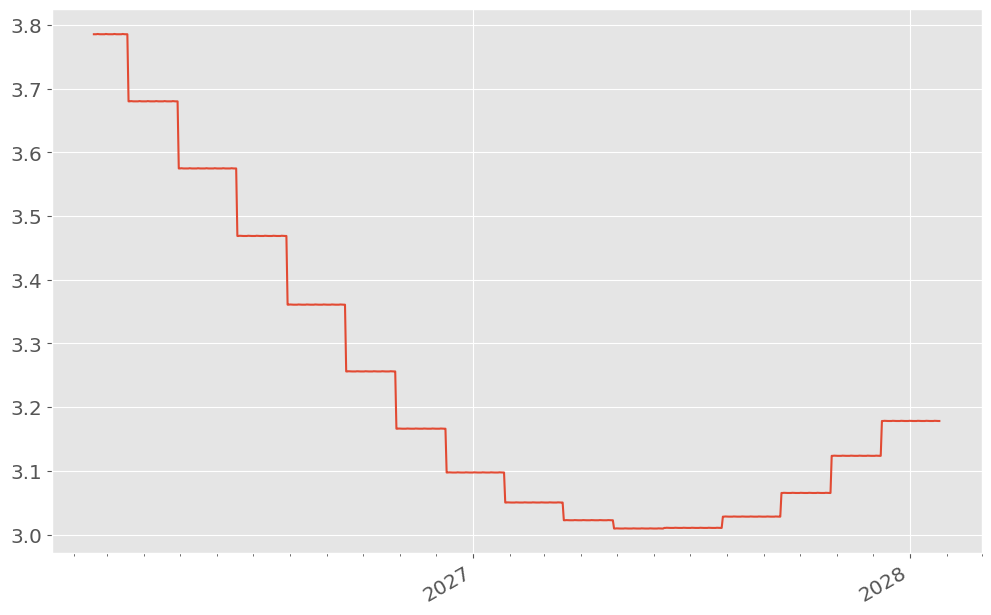

In [23]:
curves.plot("1d")

In [8]:
curve.plot("1d")

NameError: name 'curve' is not defined

In [9]:
fomc_dated_ois = {
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

In [10]:
build_fomc_ois(meeting="mar26", rl_curve=curves[NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))], risk=10_000).rate()

<Dual: 3.632451, (USD-OIS1, USD-OIS0, USD-OIS2, ...), [863.3, 0.0, -867.0, ...]>

In [6]:
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# must be timezone-aware
chi_tz = pytz.timezone("America/Chicago")
ts = chi_tz.localize(datetime.datetime(2026, 2, 13, 13, 27))

_ = mdp.get_data(
    {
        "symbols": ["SFRZ26"],
        "timestamp": ts,
        # "force_refresh": True,
        # "cache_full_intraday_fetch": True,
    }
)

In [13]:
bcf = BarchartFetcher()

ticker = "EBZ26"

df = bcf.barchart_timeseries_api(
    barchart_symbols=[ticker],
    start_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 7, 00)),
    end_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
    interval=1,
)[ticker]

df

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.17it/s]


,Open,High,Low,Close,Volume
Date,,,,,
2026-02-17 07:00:00-05:00,98.1675,98.1675,98.1675,98.1675,1
2026-02-17 07:03:00-05:00,98.1650,98.1650,98.1650,98.1650,4
2026-02-17 07:04:00-05:00,98.1675,98.1675,98.1650,98.1650,9
2026-02-17 07:06:00-05:00,98.1675,98.1675,98.1675,98.1675,7
2026-02-17 07:12:00-05:00,98.1675,98.1675,98.1675,98.1675,256
...,...,...,...,...,...
2026-02-17 13:58:00-05:00,98.1525,98.1525,98.1525,98.1525,1
2026-02-17 13:59:00-05:00,98.1525,98.1525,98.1525,98.1525,1
2026-02-17 14:38:00-05:00,98.1525,98.1525,98.1525,98.1525,15


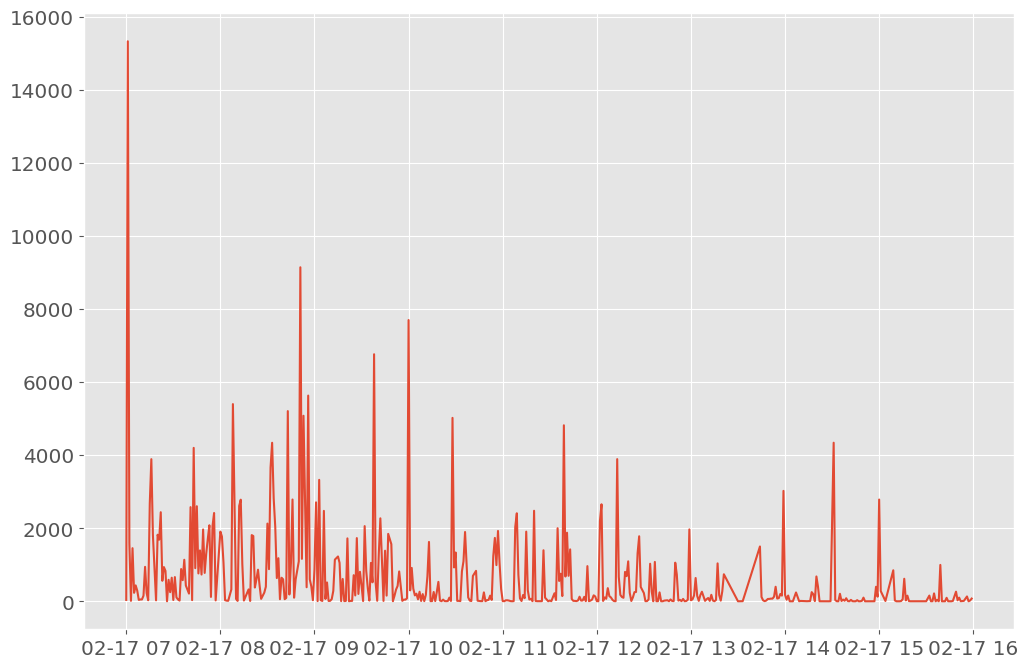

In [25]:
plt.plot(df.index, df["Volume"])